In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from matplotlib.ticker import FuncFormatter
from functions import fingerprint

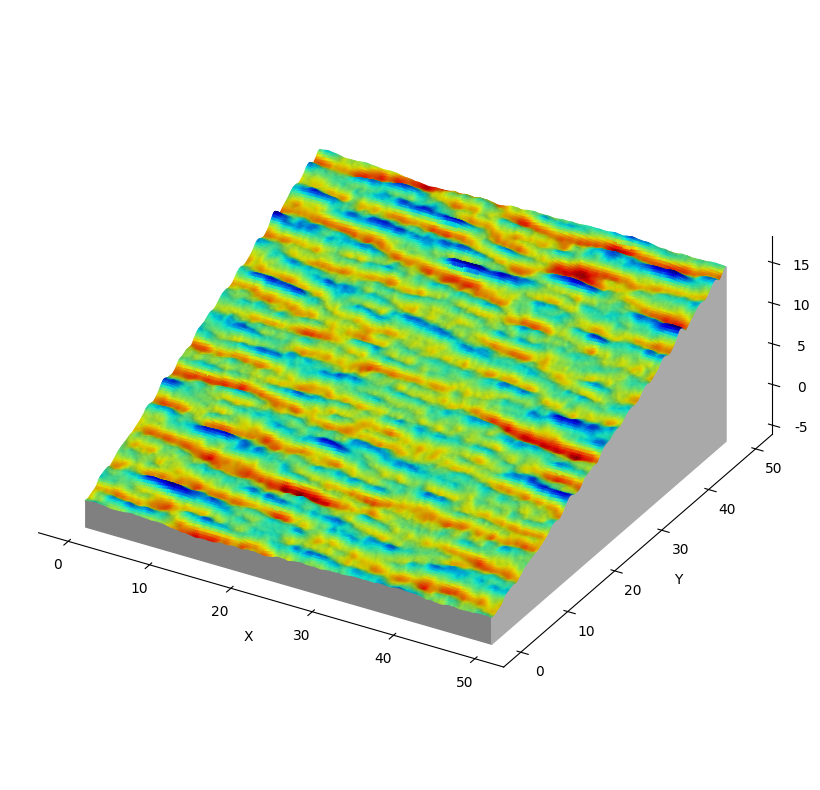

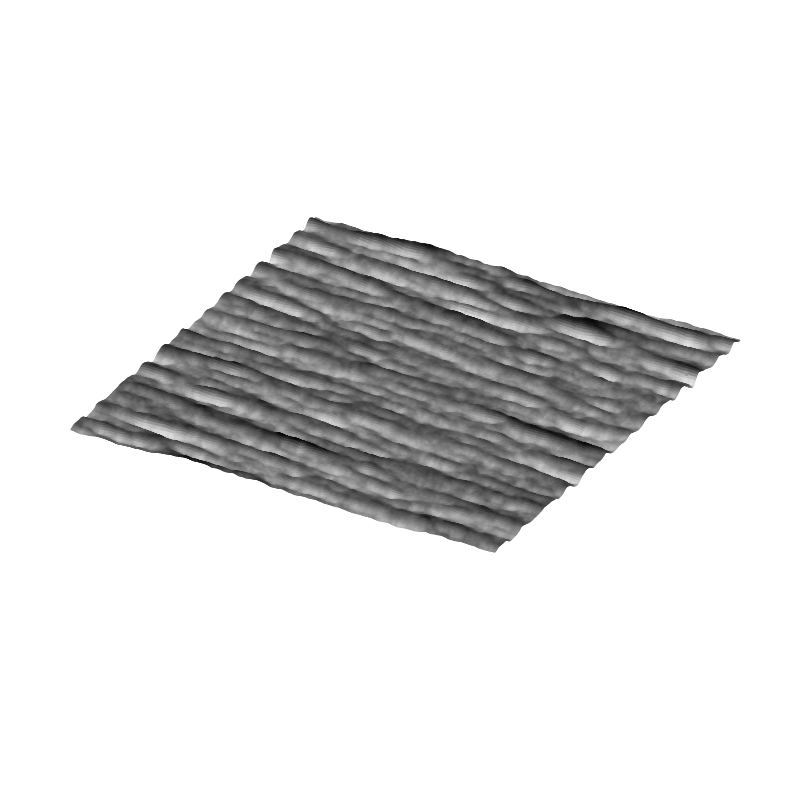

In [3]:
resolution = 10

slopes = np.array([0, 20, 40])
# particular repeats to plot
repeats = np.array([8, 3, 5])
numN = np.array([3, 3, 3])

#np_df = np.genfromtxt('Dec_20_sim/results.csv', delimiter=',')

fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(111, projection='3d', proj_type='ortho')

np_df = np.genfromtxt('fig06/results.csv', delimiter=',')
elevation_map = np.load(f'fig06/maps/elevation_map_20.npy')
trampled = np.load(f'fig06/maps/trampled_20_50_3_9.npy')
total_erosion = trampled-elevation_map
total_erosion = -(total_erosion - np.max(total_erosion))

z_min = trampled.min() - 25  # Adjust to control the depth

# Determine the z-bounds for plotting
max_height = np.max(elevation_map)
min_height = np.min(trampled) - 25

#norm = plt.Normalize(min_erosion, max_erosion)
norm = mpl.colors.Normalize(vmin=0, vmax=1.5*resolution)

# Scale tick labels by 10
def scale_ticks(val, pos):
    return f'{int(val / 10)}'

# Create a grid for the surface plot
x = np.arange(elevation_map.shape[0])
y = np.arange(elevation_map.shape[1])
x, y = np.meshgrid(x, y)

# Create the figure and axis
colors = plt.cm.jet(norm(total_erosion))
ax.plot_surface(x, y, trampled, facecolors=colors, cstride=2, rstride=2)

# Define and add the side "walls" using Poly3DCollection
verts_bottom = [
    # Bottom edge wall
    [(x[0, i], y[0, i], trampled[0, i]) for i in range(x.shape[1])] +
    [(x[0, i], y[0, i], z_min) for i in range(x.shape[1])][::-1],
]
verts_right = [
    # Right edge wall
    [(x[i, -1], y[i, -1], trampled[i, -1]) for i in range(x.shape[0])] +
    [(x[i, -1], y[i, -1], z_min) for i in range(x.shape[0])][::-1]
]
# Add walls as polygons with Poly3DCollection
poly_bottom = Poly3DCollection(verts_bottom, color='gray', alpha=1)
ax.add_collection3d(poly_bottom)
poly_right = Poly3DCollection(verts_right, color='darkgray', alpha=1)
ax.add_collection3d(poly_right)

ax.set_zlim(min_height, max_height)

ax.xaxis.set_major_formatter(FuncFormatter(scale_ticks))
ax.yaxis.set_major_formatter(FuncFormatter(scale_ticks))
ax.zaxis.set_major_formatter(FuncFormatter(scale_ticks))

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

ax.grid(False)
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))

ax.set_aspect('equal')
#ax.set_box_aspect(None, zoom=0.85)

plt.show()

slopes = np.array([0, 20, 40])
# particular repeats to plot
repeats = np.array([8, 3, 5])
numN = np.array([3, 3, 3])

#np_df = np.genfromtxt('Dec_20_sim/results.csv', delimiter=',')

fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(111, projection='3d', proj_type='ortho')

total_erosion = trampled-elevation_map
total_erosion = -(total_erosion - np.max(total_erosion))

z_min = trampled.min() - 25  # Adjust to control the depth

# Determine the z-bounds for plotting
max_height = np.max(elevation_map)
min_height = np.min(trampled) - 25

norm = mpl.colors.Normalize(vmin=0, vmax=1.5*resolution)

# Create a grid for the surface plot
x = np.arange(elevation_map.shape[0])
y = np.arange(elevation_map.shape[1])
x, y = np.meshgrid(x, y)

# Create the figure and axis
colors = plt.cm.Greys(norm(total_erosion))
ax.plot_surface(x, y, total_erosion+600, facecolors=colors, cstride=2, rstride=2)

ax.axis('off')

ax.grid(False)
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))

ax.set_aspect('equal')



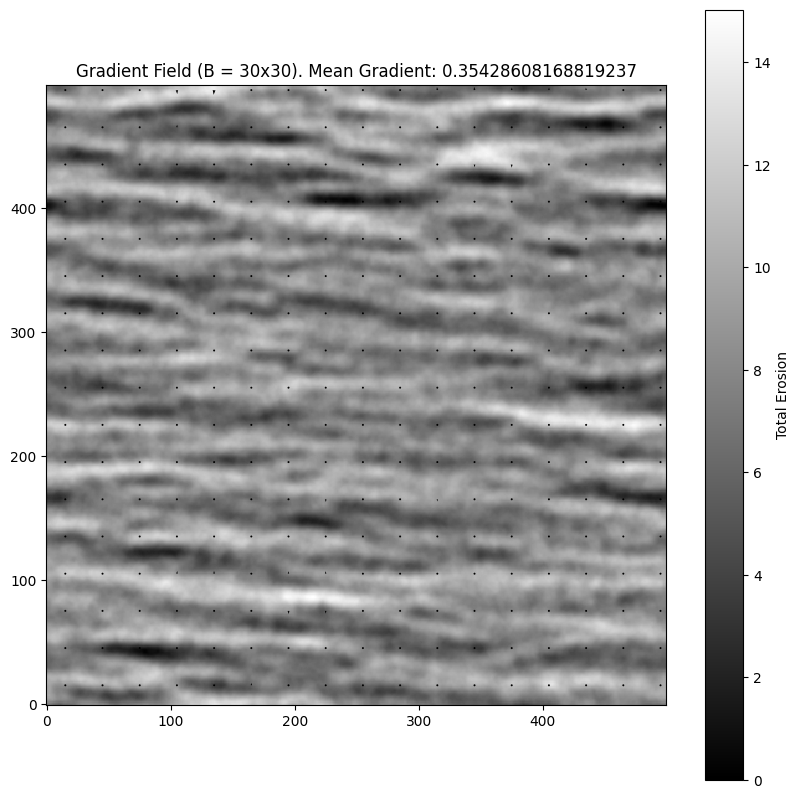

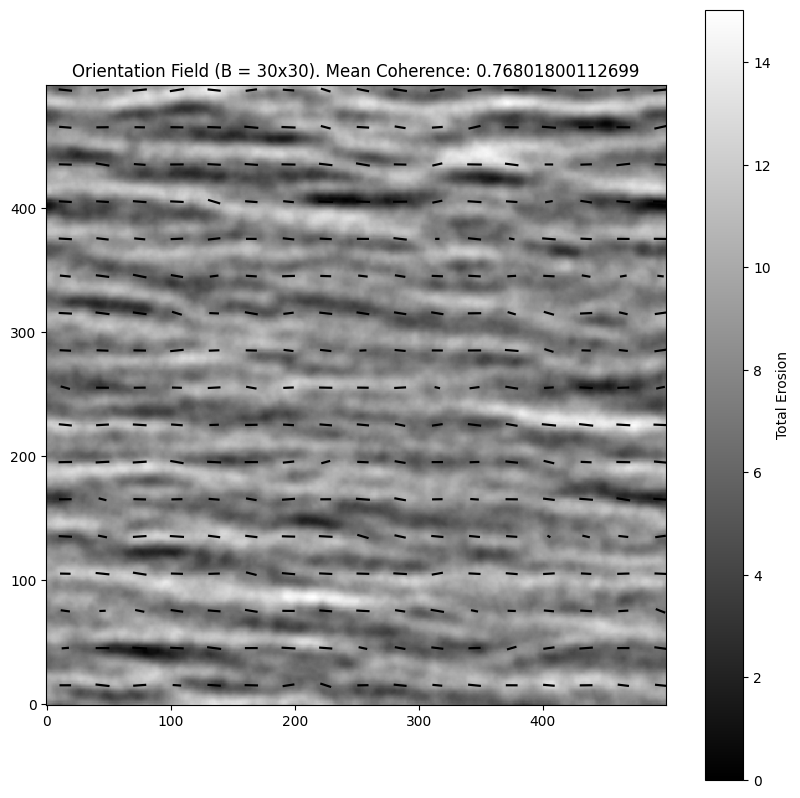

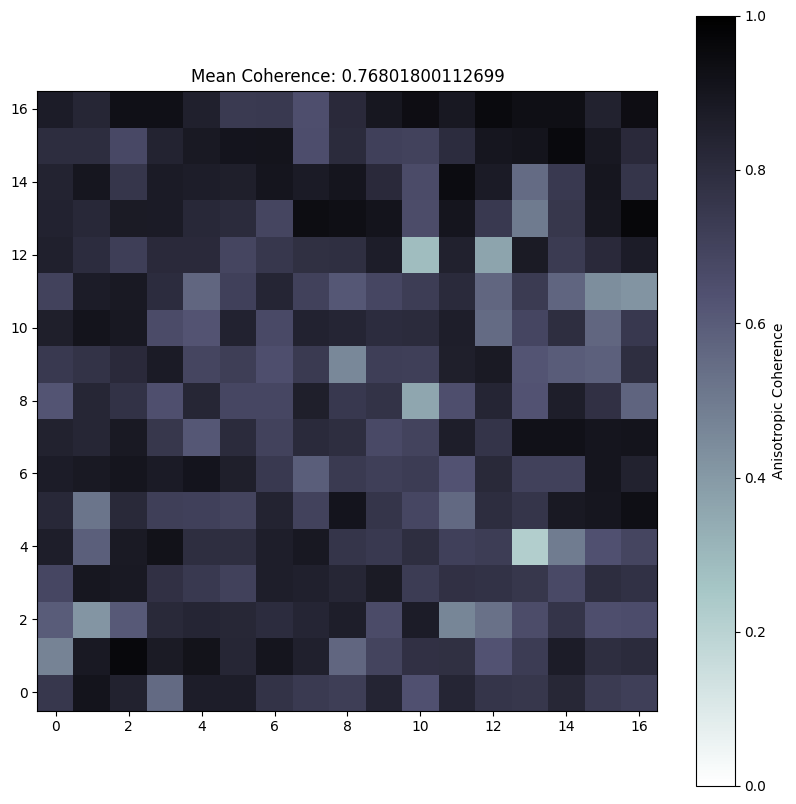

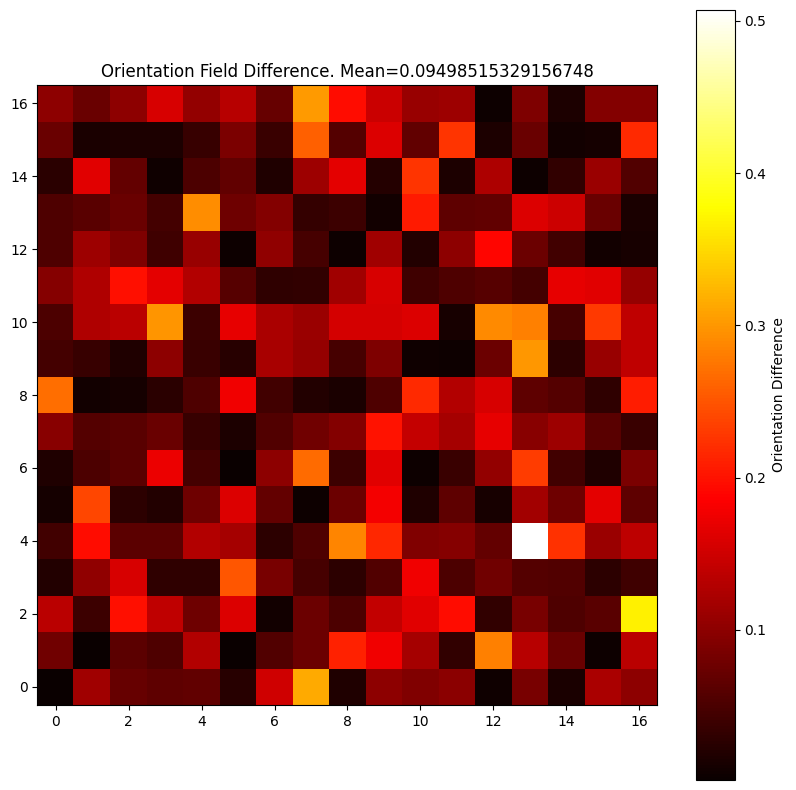

0.76801800112699


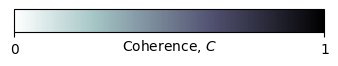

In [4]:
omega = 30
GT, _, _ = fingerprint(elevation_map, omega, ground_truth=None, plot=False)
theta, mean_gradient, mean_coherence, mean_difference = fingerprint(total_erosion, omega, ground_truth=GT, plot=True)
print(mean_coherence)

cmap = plt.cm.bone_r  # Replace with your chosen colormap
norm = mpl.colors.Normalize(vmin=0, vmax=1)  # Assuming min_erosion and max_erosion are defined

# Create a standalone colorbar figure
fig, ax = plt.subplots(figsize=(4, 0.6))
fig.subplots_adjust(bottom=0.5)  # Adjust layout for better placement

# Create a colorbar
labels = np.array([0, 1])

cbar = mpl.colorbar.ColorbarBase(ax, cmap=cmap, norm=norm, orientation='horizontal', ticks=labels)

# Add a label
cbar.set_label('Coherence, $C$', labelpad=-13)